# Step Size Comparison: Optimal vs. Conservative

This experiment compares three step size strategies for asynchronous sheaf
diffusion on a 4-regular graph with semi-orthogonal restriction maps:

- **Synchronous $1/K$**: the optimal synchronous step size, applied to the
  synchronous gradient descent baseline.
- **Asynchronous $1/K$**: the synchronous-optimal step size applied to the
  asynchronous algorithm (ignoring delay). Converges in practice for moderate $B$.
- **Conservative $0.1/K$**: a smaller step that is provably safe even with
  large delay, at the cost of slower convergence.

**Data source:** Pre-generated by `docs/scripts/acc26_experiments.jl`.

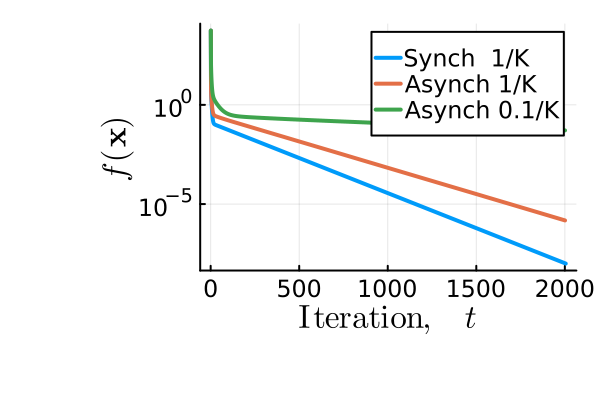

In [1]:
using CellularSheaves
using Plots
using LaTeXStrings

const data_root = joinpath(@__DIR__, "../../../data/asynch/ss_vs_converge")

subsample(v, n=2000) = v[1:max(1, length(v) ÷ n):end]

plt = empty_experiment_plot(;
    xlabel=L"\mathrm{Iteration},\quad t",
    ylabel=L"f(\mathbf{x})",
    legend=:topright,
)

for (fname, lab) in [
    ("loss_synch.csv",     "Synch  1/K"),
    ("loss_synch_ss.csv",  "Asynch 1/K"),
    ("loss_asynch_ss.csv", "Asynch 0.1/K"),
]
    path = joinpath(data_root, fname)
    isfile(path) || continue
    loss = subsample(vec(load_trajectory(path)))
    plot_log_loss_curve!(plt, loss, lab)
end

plt